In [1]:
# ═══════════════════════════════════════════════════════════
# Cell 1 — 导入 & 加载
# ═══════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import defaultdict
from sklearn.ensemble        import GradientBoostingClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics         import confusion_matrix, classification_report


In [2]:


sns.set_theme(style="whitegrid", palette="muted")
OUT_DIR = Path("kg_output")
SEED    = 42

nodes_df = pd.read_csv(OUT_DIR / "kg_nodes.csv")
edges_df = pd.read_csv(OUT_DIR / "kg_edges.csv")
X_img    = np.load(OUT_DIR / "img_embeddings.npy")
y_bin    = np.load(OUT_DIR / "img_labels.npy")

print(f"Loaded: X_img={X_img.shape}")



Loaded: X_img=(689, 2048)


In [3]:

# ═══════════════════════════════════════════════════════════
# Cell 2 — 重建特征矩阵（与 XAI 一致）
# ═══════════════════════════════════════════════════════════
import pyarrow.parquet as pq
DATA_DIR = Path("Dataset/Data")

def load_filenames(path):
    df = pq.read_table(path, columns=["filename","annotation"]).to_pandas()
    return df["filename"].tolist(), df["annotation"].tolist()

train_fns, train_anns = load_filenames(DATA_DIR / "train-00000-of-00001.parquet")
test_fns,  test_anns  = load_filenames(DATA_DIR / "test-00000-of-00001.parquet")
all_fns  = train_fns + test_fns
all_anns = train_anns + test_anns

img_nodes = nodes_df[nodes_df.label=="FundusImage"][["id","filename"]].rename(columns={"id":"img_id"})
has_diag  = edges_df[edges_df.rel=="HAS_DIAGNOSIS"][["src","dst"]].rename(columns={"src":"img_id","dst":"diag_id"})
has_od    = edges_df[edges_df.rel=="HAS_OPTIC_DISC"][["src","dst"]].rename(columns={"src":"img_id","dst":"od_id"})
has_rim   = edges_df[edges_df.rel=="HAS_RIM"][["src","dst"]].rename(columns={"src":"img_id","dst":"rim_id"})
has_path  = edges_df[edges_df.rel=="HAS_PATHOLOGY"][["src","dst"]].rename(columns={"src":"img_id","dst":"path_id"})

od_cols   = nodes_df[nodes_df.label=="OpticDisc"][["id","cup_to_disc_ratio","sharp_edge"]].rename(columns={"id":"od_id"})
rim_cols  = nodes_df[nodes_df.label=="NeuralRim"][["id","isnt_rule_followed","rim_pallor","rim_thinning"]].rename(columns={"id":"rim_id"})
path_cols = nodes_df[nodes_df.label=="Pathology"][["id","bayoneting","notching","laminar_dot_sign"]].rename(columns={"id":"path_id"})

master = (img_nodes.merge(has_diag, on="img_id")
                   .merge(has_od,   on="img_id")
                   .merge(has_rim,  on="img_id")
                   .merge(has_path, on="img_id")
                   .merge(od_cols,  on="od_id")
                   .merge(rim_cols, on="rim_id")
                   .merge(path_cols,on="path_id"))

bool_cols = ["sharp_edge","isnt_rule_followed","rim_pallor","rim_thinning",
             "bayoneting","notching","laminar_dot_sign"]
for c in bool_cols:
    master[c] = master[c].map({True:1,False:0,"True":1,"False":0}).fillna(0).astype(float)
master["cup_to_disc_ratio"] = pd.to_numeric(master["cup_to_disc_ratio"], errors="coerce").fillna(0.0)
master["isnt_violated"]     = 1 - master["isnt_rule_followed"]

# KG chain features
sup_edges    = edges_df[edges_df.rel=="SUPPORTS_RULE"].copy()
rules_df_kg  = nodes_df[nodes_df.label=="ClinicalRule"].copy()
strength_map = {str(r["id"]): str(r["strength"]).strip().lower()
                for _, r in rules_df_kg.iterrows()}

diag_counts = defaultdict(lambda: {"strong":0,"moderate":0,"weak":0})
for _, row in sup_edges.iterrows():
    d = str(row["src"]); r = str(row["dst"])
    diag_counts[d][strength_map.get(r,"weak")] += 1

chain_recs = [{"diag_id": d,
               "chain_score": c["strong"]*3+c["moderate"]*2+c["weak"],
               "n_strong":    c["strong"],
               "n_moderate":  c["moderate"],
               "n_weak":      c["weak"],
               "n_rules":     sum(c.values())}
              for d, c in diag_counts.items()]
chain_df = pd.DataFrame(chain_recs)
master   = master.merge(chain_df, on="diag_id", how="left")
for col in ["chain_score","n_strong","n_moderate","n_weak","n_rules"]:
    master[col] = master[col].fillna(0)

BIO_COLS = ["cup_to_disc_ratio","isnt_violated","rim_pallor","rim_thinning",
            "sharp_edge","bayoneting","notching","laminar_dot_sign"]
KG_COLS  = ["chain_score","n_strong","n_moderate","n_weak","n_rules"]
ALL_FEAT = BIO_COLS + KG_COLS

fn_to_row = master.set_index("filename")
X_bio_kg  = []
for fn in all_fns:
    if fn in fn_to_row.index:
        row = fn_to_row.loc[fn]
        X_bio_kg.append([float(row.get(c,0)) for c in ALL_FEAT])
    else:
        X_bio_kg.append([0.0]*len(ALL_FEAT))
X_bio_kg = np.array(X_bio_kg)

# KG chain score (for fusion)
chain_scores = X_bio_kg[:, ALL_FEAT.index("chain_score")]
chain_norm   = (chain_scores - chain_scores.min()) / (chain_scores.max() - chain_scores.min() + 1e-8)

print(f"Feature matrix: {X_bio_kg.shape}")



Feature matrix: (689, 13)


In [4]:

# ═══════════════════════════════════════════════════════════
# Cell 3 — 训练模型，收集预测结果
# ═══════════════════════════════════════════════════════════
from sklearn.preprocessing import StandardScaler

Xtr_img, Xte_img, ytr, yte, idx_tr, idx_te = train_test_split(
    X_img, y_bin, np.arange(len(y_bin)),
    test_size=0.2, stratify=y_bin, random_state=SEED
)

scaler = StandardScaler()
Xtr_s  = scaler.fit_transform(Xtr_img)
Xte_s  = scaler.transform(Xte_img)

clf = GradientBoostingClassifier(n_estimators=100, random_state=SEED)
clf.fit(Xtr_s, ytr)

img_prob_te = clf.predict_proba(Xte_s)[:, 1]
chain_te    = chain_norm[idx_te]

# 融合（α=0.5，最优）
fused_prob = 0.5 * img_prob_te + 0.5 * chain_te
y_pred     = (fused_prob >= 0.5).astype(int)

print("=== Classification Report ===")
print(classification_report(yte, y_pred, target_names=["normal","glaucoma"]))

# 混淆矩阵
cm = confusion_matrix(yte, y_pred)
tn, fp, fn_n, tp = cm.ravel()
print(f"TN={tn}  FP={fp}  FN={fn_n}  TP={tp}")



=== Classification Report ===
              precision    recall  f1-score   support

      normal       0.98      1.00      0.99        52
    glaucoma       1.00      0.99      0.99        86

    accuracy                           0.99       138
   macro avg       0.99      0.99      0.99       138
weighted avg       0.99      0.99      0.99       138

TN=52  FP=0  FN=1  TP=85


In [5]:

# ═══════════════════════════════════════════════════════════
# Cell 4 — 构建错误案例 DataFrame
# ═══════════════════════════════════════════════════════════
test_fns_arr  = np.array(all_fns)[idx_te]
test_anns_arr = np.array(all_anns)[idx_te]

error_df = pd.DataFrame({
    "filename":   test_fns_arr,
    "annotation": test_anns_arr,
    "y_true":     yte,
    "y_pred":     y_pred,
    "img_prob":   img_prob_te,
    "chain_norm": chain_te,
    "fused_prob": fused_prob,
    "error_type": ["TP" if t==1 and p==1
                   else "TN" if t==0 and p==0
                   else "FP" if t==0 and p==1
                   else "FN"
                   for t, p in zip(yte, y_pred)]
})

# 连接 biomarker 特征
bio_te = X_bio_kg[idx_te]
for i, feat in enumerate(ALL_FEAT):
    error_df[feat] = bio_te[:, i]

print("Error type distribution:")
print(error_df["error_type"].value_counts())

fp_df = error_df[error_df.error_type == "FP"]
fn_df = error_df[error_df.error_type == "FN"]
print(f"\nFalse Positives (normal→glaucoma): {len(fp_df)}")
print(f"False Negatives (glaucoma→normal): {len(fn_df)}")


Error type distribution:
error_type
TP    85
TN    52
FN     1
Name: count, dtype: int64

False Positives (normal→glaucoma): 0
False Negatives (glaucoma→normal): 1


=== Biomarker comparison: TP vs FN (glaucoma cases) ===
                   TP (correct)  FN (missed)
cup_to_disc_ratio         0.767          0.7
isnt_violated             1.000          1.0
rim_pallor                0.694          0.0
rim_thinning              1.000          1.0
sharp_edge                0.788          1.0
bayoneting                0.741          0.0
notching                  0.729          0.0
laminar_dot_sign          0.541          0.0

=== KG feature comparison: TP vs FN ===
             TP (correct)  FN (missed)
chain_score        15.906          9.0
n_strong            3.671          3.0
n_moderate          2.176          0.0
n_weak              0.541          0.0
n_rules             6.388          3.0


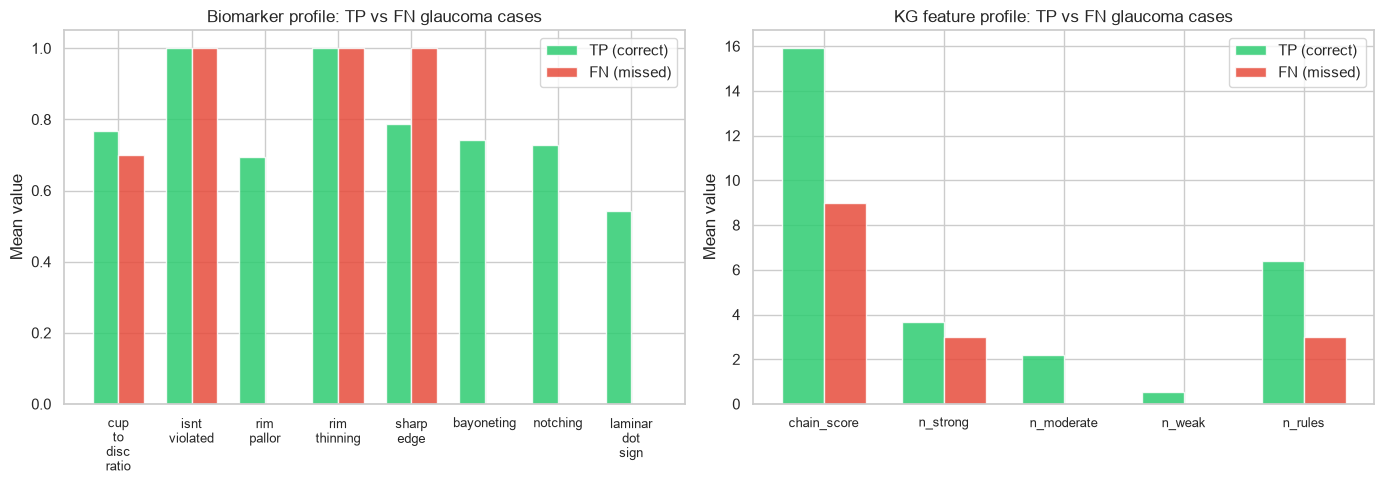

In [6]:


# ═══════════════════════════════════════════════════════════
# Cell 5 — 错误案例 Biomarker 分析
# ═══════════════════════════════════════════════════════════
tp_df = error_df[error_df.error_type == "TP"]
tn_df = error_df[error_df.error_type == "TN"]

print("=== Biomarker comparison: TP vs FN (glaucoma cases) ===")
glaucoma_bio = pd.DataFrame({
    "TP (correct)": tp_df[BIO_COLS].mean(),
    "FN (missed)":  fn_df[BIO_COLS].mean() if len(fn_df) > 0 else pd.Series(0, index=BIO_COLS),
}).round(3)
print(glaucoma_bio)

print("\n=== KG feature comparison: TP vs FN ===")
glaucoma_kg = pd.DataFrame({
    "TP (correct)": tp_df[KG_COLS].mean(),
    "FN (missed)":  fn_df[KG_COLS].mean() if len(fn_df) > 0 else pd.Series(0, index=KG_COLS),
}).round(3)
print(glaucoma_kg)

# 可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biomarker 对比
x = np.arange(len(BIO_COLS))
w = 0.35
tp_vals = tp_df[BIO_COLS].mean().values
fn_vals = fn_df[BIO_COLS].mean().values if len(fn_df) > 0 else np.zeros(len(BIO_COLS))
axes[0].bar(x - w/2, tp_vals, w, label="TP (correct)", color="#2ecc71", alpha=0.85)
axes[0].bar(x + w/2, fn_vals, w, label="FN (missed)",  color="#e74c3c", alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([c.replace("_","\n") for c in BIO_COLS], fontsize=9)
axes[0].set_ylabel("Mean value")
axes[0].set_title("Biomarker profile: TP vs FN glaucoma cases")
axes[0].legend()

# KG feature 对比
x2 = np.arange(len(KG_COLS))
tp_kg = tp_df[KG_COLS].mean().values
fn_kg = fn_df[KG_COLS].mean().values if len(fn_df) > 0 else np.zeros(len(KG_COLS))
axes[1].bar(x2 - w/2, tp_kg, w, label="TP (correct)", color="#2ecc71", alpha=0.85)
axes[1].bar(x2 + w/2, fn_kg, w, label="FN (missed)",  color="#e74c3c", alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(KG_COLS, fontsize=9)
axes[1].set_ylabel("Mean value")
axes[1].set_title("KG feature profile: TP vs FN glaucoma cases")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "error_tp_vs_fn.png", dpi=150)
plt.show()



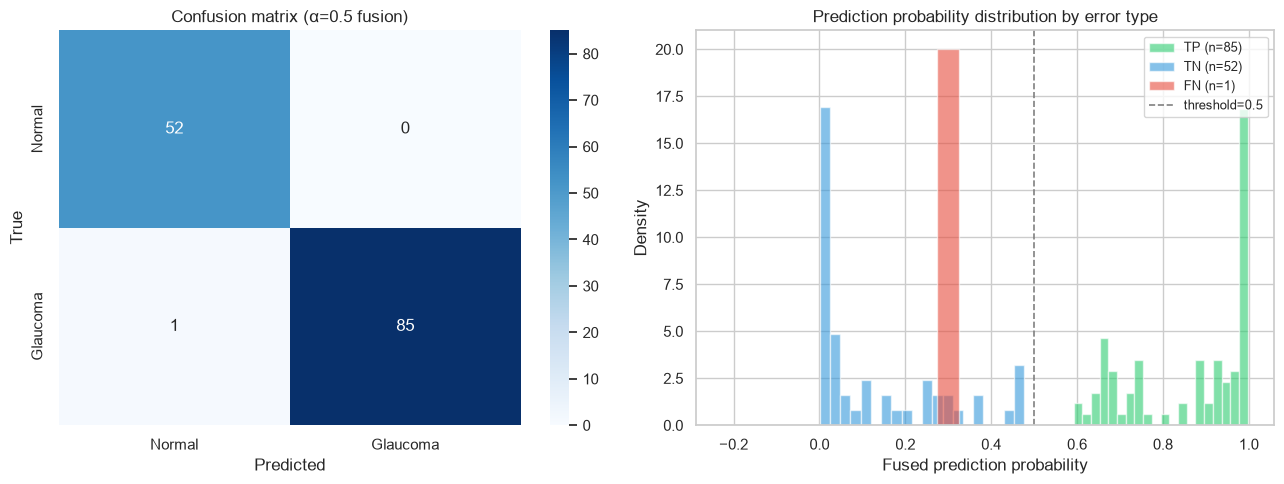

In [7]:

# ═══════════════════════════════════════════════════════════
# Cell 6 — 混淆矩阵 + 概率分布
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 混淆矩阵
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Glaucoma"],
            yticklabels=["Normal","Glaucoma"], ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion matrix (α=0.5 fusion)")

# 预测概率分布（按错误类型）
for etype, color in [("TP","#2ecc71"),("TN","#3498db"),
                      ("FP","#e67e22"),("FN","#e74c3c")]:
    sub = error_df[error_df.error_type == etype]["fused_prob"]
    if len(sub) > 0:
        axes[1].hist(sub, bins=20, alpha=0.6, color=color,
                     label=f"{etype} (n={len(sub)})", density=True)
axes[1].axvline(0.5, color="gray", linestyle="--", linewidth=1.2, label="threshold=0.5")
axes[1].set_xlabel("Fused prediction probability")
axes[1].set_ylabel("Density")
axes[1].set_title("Prediction probability distribution by error type")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "error_confusion_dist.png", dpi=150)
plt.show()


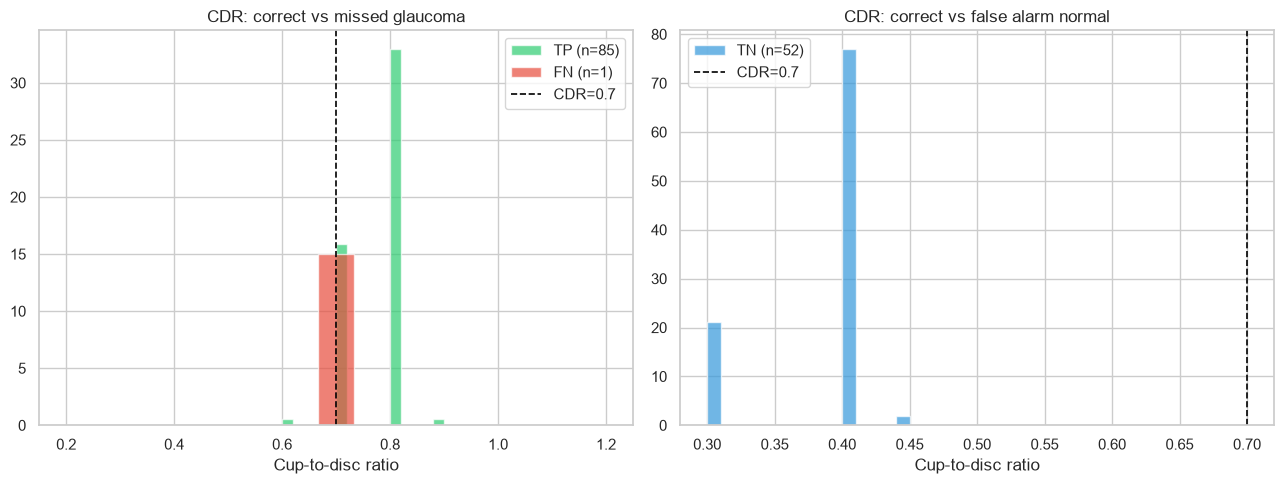

In [8]:


# ═══════════════════════════════════════════════════════════
# Cell 7 — CDR 分布：错误 vs 正确案例
# ═══════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Glaucoma 内部：TP vs FN
axes[0].hist(tp_df["cup_to_disc_ratio"], bins=15, alpha=0.7,
             color="#2ecc71", label=f"TP (n={len(tp_df)})", density=True)
if len(fn_df) > 0:
    axes[0].hist(fn_df["cup_to_disc_ratio"], bins=15, alpha=0.7,
                 color="#e74c3c", label=f"FN (n={len(fn_df)})", density=True)
axes[0].axvline(0.7, color="black", linestyle="--", linewidth=1.2, label="CDR=0.7")
axes[0].set_xlabel("Cup-to-disc ratio")
axes[0].set_title("CDR: correct vs missed glaucoma")
axes[0].legend()

# Normal 内部：TN vs FP
axes[1].hist(tn_df["cup_to_disc_ratio"], bins=15, alpha=0.7,
             color="#3498db", label=f"TN (n={len(tn_df)})", density=True)
if len(fp_df) > 0:
    axes[1].hist(fp_df["cup_to_disc_ratio"], bins=15, alpha=0.7,
                 color="#e67e22", label=f"FP (n={len(fp_df)})", density=True)
axes[1].axvline(0.7, color="black", linestyle="--", linewidth=1.2, label="CDR=0.7")
axes[1].set_xlabel("Cup-to-disc ratio")
axes[1].set_title("CDR: correct vs false alarm normal")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT_DIR / "error_cdr_analysis.png", dpi=150)
plt.show()



In [9]:

# ═══════════════════════════════════════════════════════════
# Cell 8 — 汇总：论文 Discussion 数据
# ═══════════════════════════════════════════════════════════
print("=" * 60)
print("Error Analysis Summary for Paper Discussion")
print("=" * 60)
print(f"\nTest set: {len(error_df)} samples")
print(f"  TP: {len(tp_df):3d} ({len(tp_df)/len(error_df)*100:.1f}%)")
print(f"  TN: {len(tn_df):3d} ({len(tn_df)/len(error_df)*100:.1f}%)")
print(f"  FP: {len(fp_df):3d} ({len(fp_df)/len(error_df)*100:.1f}%)")
print(f"  FN: {len(fn_df):3d} ({len(fn_df)/len(error_df)*100:.1f}%)")

if len(fn_df) > 0:
    print(f"\nFN analysis (missed glaucoma):")
    print(f"  Avg CDR          : {fn_df['cup_to_disc_ratio'].mean():.3f}  "
          f"(TP avg: {tp_df['cup_to_disc_ratio'].mean():.3f})")
    print(f"  Avg chain_score  : {fn_df['chain_score'].mean():.2f}  "
          f"(TP avg: {tp_df['chain_score'].mean():.2f})")
    print(f"  Avg n_rules      : {fn_df['n_rules'].mean():.2f}  "
          f"(TP avg: {tp_df['n_rules'].mean():.2f})")
    print(f"  rim_thinning rate: {fn_df['rim_thinning'].mean()*100:.1f}%  "
          f"(TP: {tp_df['rim_thinning'].mean()*100:.1f}%)")

if len(fp_df) > 0:
    print(f"\nFP analysis (false alarms):")
    print(f"  Avg CDR          : {fp_df['cup_to_disc_ratio'].mean():.3f}  "
          f"(TN avg: {tn_df['cup_to_disc_ratio'].mean():.3f})")
    print(f"  Avg chain_score  : {fp_df['chain_score'].mean():.2f}  "
          f"(TN avg: {tn_df['chain_score'].mean():.2f})")

print(f"\nFigures saved:")
print(f"  kg_output/error_tp_vs_fn.png")
print(f"  kg_output/error_confusion_dist.png")
print(f"  kg_output/error_cdr_analysis.png")

Error Analysis Summary for Paper Discussion

Test set: 138 samples
  TP:  85 (61.6%)
  TN:  52 (37.7%)
  FP:   0 (0.0%)
  FN:   1 (0.7%)

FN analysis (missed glaucoma):
  Avg CDR          : 0.700  (TP avg: 0.767)
  Avg chain_score  : 9.00  (TP avg: 15.91)
  Avg n_rules      : 3.00  (TP avg: 6.39)
  rim_thinning rate: 100.0%  (TP: 100.0%)

Figures saved:
  kg_output/error_tp_vs_fn.png
  kg_output/error_confusion_dist.png
  kg_output/error_cdr_analysis.png
